In [8]:
import os
import zipfile
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import plotly.express as px
from sklearn.preprocessing import LabelEncoder

In [9]:
db_path = './dataset/'

studentVle  = pd.read_csv(os.path.join(db_path,"studentVle.csv"))
studentAssessment  = pd.read_csv(os.path.join(db_path,"studentAssessment.csv"))
studentInfo  = pd.read_csv(os.path.join(db_path,"studentInfo.csv"))
studentRegistration = pd.read_csv(os.path.join(db_path,"studentRegistration.csv"))
courses = pd.read_csv(os.path.join(db_path,"courses.csv"))
assessments = pd.read_csv(os.path.join(db_path,"assessments.csv"))
vle=pd.read_csv(os.path.join(db_path,"vle.csv"))

In [10]:
student_data = pd.merge(studentRegistration, studentInfo, on=['id_student', 'code_module', 'code_presentation'], how='inner')

In [11]:
student_data = pd.merge(student_data, courses, on=['code_module', 'code_presentation'], how='inner')

In [12]:
studentAssessment.shape

(173912, 5)

In [13]:
assessments.shape

(206, 6)

In [14]:
student_assesment_data = assessments.merge(studentAssessment,on=['id_assessment'],how="inner")

In [15]:
student_assesment_data

,code_module,code_presentation,id_assessment,assessment_type,date,weight,id_student,date_submitted,is_banked,score
0,AAA,2013J,1752,TMA,19.0,10.0,11391,18,0,78.0
1,AAA,2013J,1752,TMA,19.0,10.0,28400,22,0,70.0
2,AAA,2013J,1752,TMA,19.0,10.0,31604,17,0,72.0
3,AAA,2013J,1752,TMA,19.0,10.0,32885,26,0,69.0
4,AAA,2013J,1752,TMA,19.0,10.0,38053,19,0,79.0
...,...,...,...,...,...,...,...,...,...,...
173907,GGG,2014J,37437,TMA,173.0,0.0,652462,172,0,60.0
173908,GGG,2014J,37437,TMA,173.0,0.0,652539,176,0,75.0
173909,GGG,2014J,37437,TMA,173.0,0.0,653157,187,0,70.0
173910,GGG,2014J,37437,TMA,173.0,0.0,653252,171,0,70.0


In [17]:
student_assesment_data.isna().sum()


code_module             0
code_presentation       0
id_assessment           0
assessment_type         0
date                 2865
weight                  0
id_student              0
date_submitted          0
is_banked               0
score                 173
dtype: int64

In [ ]:
missing_scores = student_assesment_data[student_assesment_data['score'].isnull()]
print(missing_scores.groupby(['assessment_type'])['id_assessment'].count())

# Handling Missing values in score column
# we can notice that all missing scores are of assesment_type TMA

assessment_type
TMA    173
Name: id_assessment, dtype: int64


In [11]:
tma_missing_scores = missing_scores[missing_scores['assessment_type'] == 'TMA']

# Check for patterns in missing scores related to other columns
print(tma_missing_scores.groupby(['code_module', 'code_presentation'])['id_assessment'].count())

code_module  code_presentation
AAA          2013J                 2
             2014J                 1
BBB          2013B                16
             2013J                10
             2014B                17
             2014J                10
CCC          2014B                 5
             2014J                 6
DDD          2013B                18
             2013J                 8
             2014B                11
             2014J                12
EEE          2013J                 3
             2014B                 2
             2014J                 2
FFF          2013B                14
             2013J                12
             2014B                11
             2014J                 9
GGG          2013J                 1
             2014B                 1
             2014J                 2
Name: id_assessment, dtype: int64


In [ ]:
# Missing score values can be interpreted as non-submissions. This means we can fill them out with zeros
student_assesment_data["score"].fillna(0, inplace=True)
student_assesment_data.dropna(inplace=True) # We can drop the nulls in date column

In [13]:
student_assesment_data.isna().sum()


code_module          0
code_presentation    0
id_assessment        0
assessment_type      0
date                 0
weight               0
id_student           0
date_submitted       0
is_banked            0
score                0
dtype: int64

In [ ]:
student_data_final = student_assesment_data.merge(student_data,on=['code_module','code_presentation','id_student'],how="inner")
# Merging the assessment data with the student data will expand the student_data because each student can have multiple assessments. This results in a larger dataset where each row now reflects a unique student-assessment combination, with additional columns detailing the assessment information. While this significantly increases the number of rows, we will address the handling of this larger dataset later.

In [ ]:
student_data_final

,code_module,code_presentation,id_assessment,assessment_type,date,weight,id_student,date_submitted,is_banked,score,...,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,module_presentation_length
0,AAA,2013J,1752,TMA,19.0,10.0,11391,18,0,78.0,...,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,268
1,AAA,2013J,1753,TMA,54.0,20.0,11391,53,0,85.0,...,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,268
2,AAA,2013J,1754,TMA,117.0,20.0,11391,115,0,80.0,...,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,268
3,AAA,2013J,1755,TMA,166.0,20.0,11391,164,0,85.0,...,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,268
4,AAA,2013J,1756,TMA,215.0,30.0,11391,212,0,82.0,...,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171042,GGG,2014J,37435,TMA,61.0,0.0,541774,60,0,56.0,...,F,Wales,Lower Than A Level,10-20,0-35,0,30,N,Fail,269
171043,GGG,2014J,37436,TMA,124.0,0.0,541774,124,0,68.0,...,F,Wales,Lower Than A Level,10-20,0-35,0,30,N,Fail,269
171044,GGG,2014J,37435,TMA,61.0,0.0,547334,59,0,54.0,...,F,East Anglian Region,HE Qualification,70-80%,35-55,0,30,N,Fail,269
171045,GGG,2014J,37436,TMA,124.0,0.0,627809,124,0,60.0,...,F,East Anglian Region,Lower Than A Level,20-30%,0-35,1,30,N,Fail,269


In [ ]:
student_data_final.isna().sum()

code_module                        0
code_presentation                  0
id_assessment                      0
assessment_type                    0
date                               0
weight                             0
id_student                         0
date_submitted                     0
is_banked                          0
score                              0
date_registration                  7
date_unregistration           157992
gender                             0
region                             0
highest_education                  0
imd_band                        7481
age_band                           0
num_of_prev_attempts               0
studied_credits                    0
disability                         0
final_result                       0
module_presentation_length         0
dtype: int64

In [ ]:
df = student_data_final.copy()

C:\Users\ishan\AppData\Local\Temp\ipykernel_580\86102169.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_null_unregistration, x='final_result', palette='viridis')


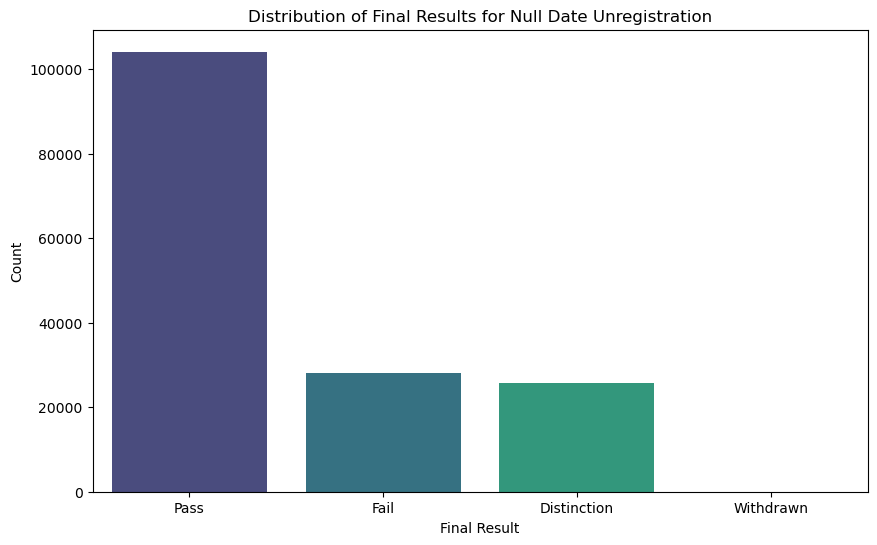

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
df_null_unregistration = df[df['date_unregistration'].isnull()]

plt.figure(figsize=(10, 6))
sns.countplot(data=df_null_unregistration, x='final_result', palette='viridis')

plt.title('Distribution of Final Results for Null Date Unregistration')
plt.xlabel('Final Result')
plt.ylabel('Count')
plt.show()

# date_Unregisteration descripes the date when the student unregisters from the moudle, Pass and Fail and Distinction means that a student finished the module, while withdrawn means that he didn't finish it

C:\Users\ishan\AppData\Local\Temp\ipykernel_580\2391851961.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_non_null_unregistration, x='final_result', palette='viridis')


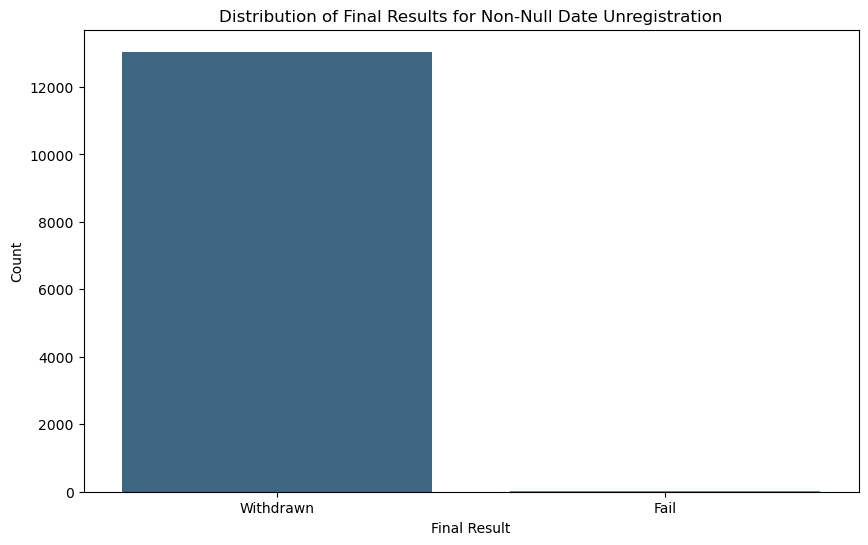

In [21]:
df_non_null_unregistration = df[df['date_unregistration'].notnull()]

plt.figure(figsize=(10, 6))
sns.countplot(data=df_non_null_unregistration, x='final_result', palette='viridis')

plt.title('Distribution of Final Results for Non-Null Date Unregistration')
plt.xlabel('Final Result')
plt.ylabel('Count')

# Show the plot
plt.show()

In [ ]:
# Since we can't Impute all of these null values, and we know that date_unregistered is null when a student doesn't complete his study, we can assign finished-unfinished label instead of date_unregisteration, if the final result is (Pass,Fail,Distinction) a student finished, if it's (Withdrawn) student didn't finish
df['study_status'] = df['final_result'].apply(lambda x: 'finished' if x in ['Pass', 'Fail', 'Distinction'] else 'unfinished')

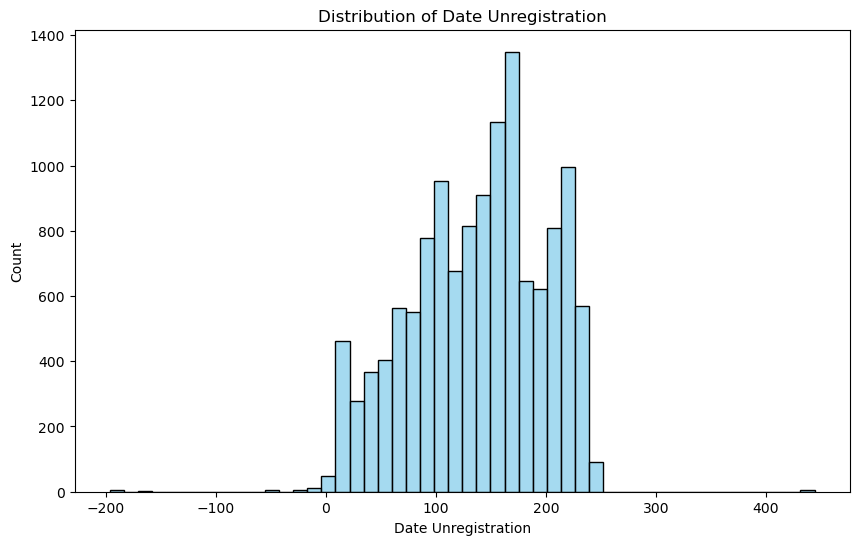

In [23]:
df_non_null = df[df['date_unregistration'].notnull()]

plt.figure(figsize=(10, 6))
sns.histplot(df_non_null['date_unregistration'], bins=50, color='skyblue')

plt.title('Distribution of Date Unregistration')
plt.xlabel('Date Unregistration')
plt.ylabel('Count')

plt.show()

In [25]:
def categorize_withdrawal(date):
    if pd.isnull(date):
        return "didn't withdraw"
    elif date < 0:
        return 'early withdrawal'
    elif date >=0 and date < 70:
        return 'normal withdrawal'
    else:
        return 'late withdrawal'

df['withdrawal_status'] = df['date_unregistration'].apply(categorize_withdrawal)

df[['date_unregistration', 'withdrawal_status']].head()

,date_unregistration,withdrawal_status
0,NaN,didn't withdraw
1,NaN,didn't withdraw
2,NaN,didn't withdraw
3,NaN,didn't withdraw
4,NaN,didn't withdraw


In [ ]:
df.drop(['date_unregistration'],axis=1,inplace=True) 
# dropping the column as it has many nulls and we already extracted useful information from it

In [27]:
df.isna().sum()

code_module                      0
code_presentation                0
id_assessment                    0
assessment_type                  0
date                             0
weight                           0
id_student                       0
date_submitted                   0
is_banked                        0
score                            0
date_registration                7
gender                           0
region                           0
highest_education                0
imd_band                      7481
age_band                         0
num_of_prev_attempts             0
studied_credits                  0
disability                       0
final_result                     0
module_presentation_length       0
study_status                     0
withdrawal_status                0
dtype: int64

In [ ]:
# imd_band specifies the Index of Multiple Depravation band of the place where the student lived during the module-presentation.
# we will fill out according to the most frequent band for that region

regions_list = df[df['imd_band'].isnull()]['region'].unique()

for region in regions_list:
  mode_imd_band = df[df['region'] == region]['imd_band'].mode()[0]
  df.loc[(df['imd_band'].isnull()) & (df['region'] == region), 'imd_band'] = mode_imd_band

In [29]:
df.isna().sum() # Only 7 records left in date_registeration
df.dropna(inplace=True)

In [ ]:
studentVle

,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1
...,...,...,...,...,...,...
10655275,GGG,2014J,675811,896943,269,3
10655276,GGG,2014J,675578,896943,269,1
10655277,GGG,2014J,654064,896943,269,3
10655278,GGG,2014J,654064,896939,269,1


In [ ]:
vle

,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN
2,546998,AAA,2013J,resource,NaN,NaN
3,546888,AAA,2013J,url,NaN,NaN
4,547035,AAA,2013J,resource,NaN,NaN
...,...,...,...,...,...,...
6359,897063,GGG,2014J,resource,NaN,NaN
6360,897109,GGG,2014J,resource,NaN,NaN
6361,896965,GGG,2014J,oucontent,NaN,NaN
6362,897060,GGG,2014J,resource,NaN,NaN


In [32]:
student_interaction = studentVle.merge(vle,on=['code_module','code_presentation','id_site'],how="inner")


In [33]:
student_interaction


,code_module,code_presentation,id_student,id_site,date,sum_click,activity_type,week_from,week_to
0,AAA,2013J,28400,546652,-10,4,forumng,NaN,NaN
1,AAA,2013J,28400,546652,-10,1,forumng,NaN,NaN
2,AAA,2013J,28400,546652,-10,1,forumng,NaN,NaN
3,AAA,2013J,28400,546652,-10,8,forumng,NaN,NaN
4,AAA,2013J,30268,546652,-10,3,forumng,NaN,NaN
...,...,...,...,...,...,...,...,...,...
10655275,GGG,2014J,647054,896969,227,8,oucontent,NaN,NaN
10655276,GGG,2014J,499187,896969,228,8,oucontent,NaN,NaN
10655277,GGG,2014J,629258,896969,228,23,oucontent,NaN,NaN
10655278,GGG,2014J,534672,896969,228,1,oucontent,NaN,NaN


In [34]:
grouped_student_interaction = student_interaction.groupby(
    ['id_student', 'code_module', 'code_presentation','activity_type'], as_index=False
)["sum_click"].agg(['sum', 'count'])

In [35]:
grouped_student_interaction


sum  count
id_student code_module code_presentation activity_type             
6516       AAA         2014J             dataplus         21      4
                                         forumng         451    175
                                         homepage        497    158
                                         oucontent      1505    184
                                         resource         31     19
...                                                      ...    ...
2698588    BBB         2014J             oucollaborate     7      7
                                         oucontent       233     74
                                         resource         49     36
                                         subpage          76     34
                                         url               2      2

[240357 rows x 2 columns]

In [36]:
merged_df = grouped_student_interaction.merge(df,
                                              on=['id_student', 'code_module', 'code_presentation'],
                                              how='inner')

In [37]:
merged_df


,id_student,code_module,code_presentation,sum,count,id_assessment,assessment_type,date,weight,date_submitted,...,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,module_presentation_length,study_status,withdrawal_status
0,6516,AAA,2014J,21,4,1758,TMA,19.0,10.0,17,...,HE Qualification,80-90%,55<=,0,60,N,Pass,269,finished,didn't withdraw
1,6516,AAA,2014J,21,4,1759,TMA,54.0,20.0,51,...,HE Qualification,80-90%,55<=,0,60,N,Pass,269,finished,didn't withdraw
2,6516,AAA,2014J,21,4,1760,TMA,117.0,20.0,116,...,HE Qualification,80-90%,55<=,0,60,N,Pass,269,finished,didn't withdraw
3,6516,AAA,2014J,21,4,1761,TMA,166.0,20.0,164,...,HE Qualification,80-90%,55<=,0,60,N,Pass,269,finished,didn't withdraw
4,6516,AAA,2014J,21,4,1762,TMA,215.0,30.0,210,...,HE Qualification,80-90%,55<=,0,60,N,Pass,269,finished,didn't withdraw
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1579980,2698588,BBB,2014J,2,2,15020,TMA,19.0,0.0,18,...,HE Qualification,30-40%,0-35,0,120,N,Distinction,262,finished,didn't withdraw
1579981,2698588,BBB,2014J,2,2,15021,TMA,54.0,10.0,53,...,HE Qualification,30-40%,0-35,0,120,N,Distinction,262,finished,didn't withdraw
1579982,2698588,BBB,2014J,2,2,15022,TMA,110.0,20.0,109,...,HE Qualification,30-40%,0-35,0,120,N,Distinction,262,finished,didn't withdraw
1579983,2698588,BBB,2014J,2,2,15023,TMA,152.0,35.0,152,...,HE Qualification,30-40%,0-35,0,120,N,Distinction,262,finished,didn't withdraw


In [38]:
merged_df.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 1579985 entries, 0 to 1579984
Data columns (total 25 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   id_student                  1579985 non-null  int64  
 1   code_module                 1579985 non-null  object 
 2   code_presentation           1579985 non-null  object 
 3   sum                         1579985 non-null  int64  
 4   count                       1579985 non-null  int64  
 5   id_assessment               1579985 non-null  int64  
 6   assessment_type             1579985 non-null  object 
 7   date                        1579985 non-null  float64
 8   weight                      1579985 non-null  float64
 9   date_submitted              1579985 non-null  int64  
 10  is_banked                   1579985 non-null  int64  
 11  score                       1579985 non-null  float64
 12  date_registration           1579985 non-null  float64
 1

In [39]:
merged_df.isna().sum()


id_student                    0
code_module                   0
code_presentation             0
sum                           0
count                         0
id_assessment                 0
assessment_type               0
date                          0
weight                        0
date_submitted                0
is_banked                     0
score                         0
date_registration             0
gender                        0
region                        0
highest_education             0
imd_band                      0
age_band                      0
num_of_prev_attempts          0
studied_credits               0
disability                    0
final_result                  0
module_presentation_length    0
study_status                  0
withdrawal_status             0
dtype: int64

In [ ]:
merged_df.to_csv("merged.csv")